# Scaling Factor Ablation

**Question:** Does scaling dot-product attention scores by `1/sqrt(d_k)` actually
prevent softmax saturation as `d_k` grows, as claimed in
*"Attention Is All You Need"* (Section 3.2.1)?

We measure average Shannon entropy (bits) of the attention distribution.
Lower entropy = more peaked / saturated softmax = smaller gradients.
Max possible entropy for a uniform distribution over `seq_len` keys is
`log2(seq_len)`.

In [1]:
import math

import matplotlib.pyplot as plt
import pandas as pd
import torch

from transformer_lab.attention.single_head import SingleHeadAttention

%matplotlib inline

## Configuration

In [2]:
cfg = {
    "d_model": 64,
    "d_k_values": [4, 8, 16, 32, 64, 128, 256],
    "seq_len": 32,
    "batch_size": 8,
    "num_trials": 20,
    "seed": 0,
}

cfg

{'d_model': 64,
 'd_k_values': [4, 8, 16, 32, 64, 128, 256],
 'seq_len': 32,
 'batch_size': 8,
 'num_trials': 20,
 'seed': 0}

## Helpers

In [3]:
def attention_entropy(weights: torch.Tensor) -> float:
    """Mean Shannon entropy (bits) across all query positions/batches."""
    eps = 1e-12
    entropy = -(weights * (weights + eps).log2()).sum(dim=-1)
    return entropy.mean().item()

## Run experiment

For each `d_k`, we compare scaled vs. unscaled softmax entropy using
`SingleHeadAttention`'s own Q/K projections, averaged over random trials.

In [4]:
torch.manual_seed(cfg["seed"])

rows = []
for d_k in cfg["d_k_values"]:
    scaled_entropies, unscaled_entropies = [], []

    for _ in range(cfg["num_trials"]):
        attn = SingleHeadAttention(d_model=cfg["d_model"], d_k=d_k, d_v=d_k)
        x = torch.randn(cfg["batch_size"], cfg["seq_len"], cfg["d_model"])

        with torch.no_grad():
            q = attn.w_q(x)
            k = attn.w_k(x)

            raw_scores = q @ k.transpose(-2, -1)
            scaled_scores = raw_scores / math.sqrt(d_k)

            scaled_weights = torch.softmax(scaled_scores, dim=-1)
            unscaled_weights = torch.softmax(raw_scores, dim=-1)

        scaled_entropies.append(attention_entropy(scaled_weights))
        unscaled_entropies.append(attention_entropy(unscaled_weights))

    rows.append({
        "d_k": d_k,
        "scaled_entropy_bits": sum(scaled_entropies) / len(scaled_entropies),
        "unscaled_entropy_bits": sum(unscaled_entropies) / len(unscaled_entropies),
        "max_possible_entropy_bits": math.log2(cfg["seq_len"]),
    })

df = pd.DataFrame(rows)
df

,d_k,scaled_entropy_bits,unscaled_entropy_bits,max_possible_entropy_bits
0,4,4.925272,4.710912,5.0
1,8,4.921036,4.417741,5.0
2,16,4.922399,3.945002,5.0
3,32,4.923624,3.265343,5.0
4,64,4.923653,2.467488,5.0
5,128,4.923662,1.746309,5.0
6,256,4.922310,1.158106,5.0


## Plot

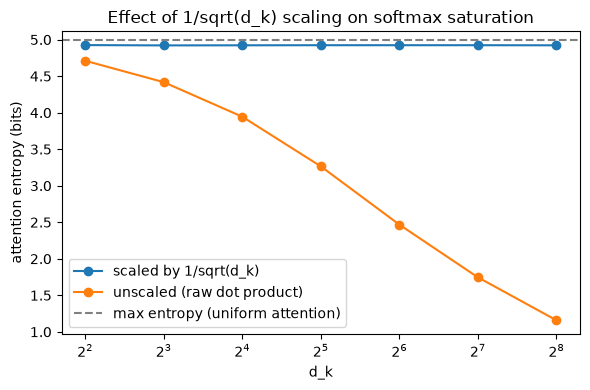

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df["d_k"], df["scaled_entropy_bits"], marker="o", label="scaled by 1/sqrt(d_k)")
ax.plot(df["d_k"], df["unscaled_entropy_bits"], marker="o", label="unscaled (raw dot product)")
ax.axhline(
    df["max_possible_entropy_bits"].iloc[0],
    color="gray",
    linestyle="--",
    label="max entropy (uniform attention)",
)
ax.set_xscale("log", base=2)
ax.set_xlabel("d_k")
ax.set_ylabel("attention entropy (bits)")
ax.set_title("Effect of 1/sqrt(d_k) scaling on softmax saturation")
ax.legend()
fig.tight_layout()
plt.show()

## Finding

**The scaling factor works as claimed.** With scaling, entropy stays
essentially flat (~4.92 bits) regardless of `d_k` — the softmax stays
close to uniform and gradient flow is preserved. Without scaling, entropy
collapses steadily as `d_k` grows: by `d_k=256` the unscaled distribution
has dropped to ~1.16 bits, meaning attention has become sharply peaked on
a small number of keys.

This follows from the dot product of two random `d_k`-dimensional vectors
having variance that scales with `d_k`. Dividing by `sqrt(d_k)` renormalizes
that variance back to ~1.

**Caveat:** This uses freshly initialized (untrained) Q/K projections,
matching the paper's initialization-time gradient-flow argument. A trained
model may learn weights that partially compensate.